Importing Libraries

In [1]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from IPython.display import display

Defining the Oracle

In [2]:
def grover_oracle():
    qc = QuantumCircuit(2)
    qc.cz(0, 1)
    return qc

Defining the Diffusion Operator

In [3]:
def grover_diffusion():
    qc = QuantumCircuit(2)
    qc.h([0, 1])
    qc.x([0, 1])
    qc.cz(0, 1)
    qc.x([0, 1])
    qc.h([0, 1])
    return qc

Assembling the Grover Circuit

In [4]:
grover_circuit = QuantumCircuit(2, 2)

grover_circuit.h([0, 1])
grover_circuit.compose(grover_oracle(), inplace=True)
grover_circuit.compose(grover_diffusion(), inplace=True)
grover_circuit.measure([0, 1], [0, 1])

Display quantum circuit chart

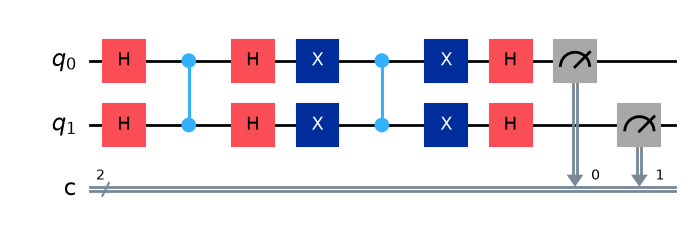

In [5]:
display(grover_circuit.draw('mpl'))

Simulating the Circuit

In [6]:
simulator = AerSimulator()
result = simulator.run(grover_circuit, shots=1024).result()
counts = result.get_counts()
print(counts)

{'11': 1024}


Visualizing the Results

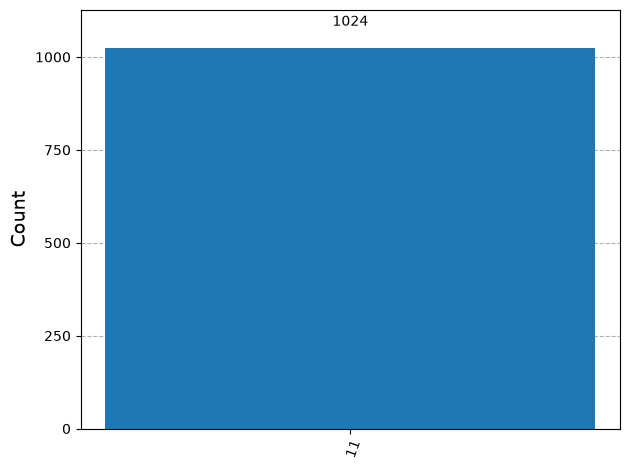

In [7]:
display(plot_histogram(counts))